MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT
PART A: PYTHON CODING
Q1. SUPERVISED LEARNING

[TASK 1: DATA LOADING AND INSPECTION]
Dataset Shape: (800, 12)

--- Column Data Types ---
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

--- Missing Value Counts ---
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

--- First 5 Rows of Data ---
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   


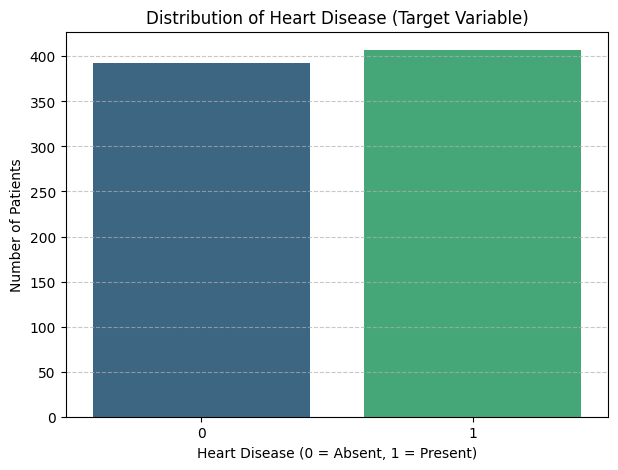


--- Interpretation: Target Variable Distribution ---
The countplot reveals that the dataset is relatively well-balanced between patients
diagnosed with heart disease (1) and those without (0). In machine learning, a
balanced dataset is ideal because it prevents the model from developing a bias
toward a 'majority' class. This ensures the algorithm learns the specific symptoms
and markers of both healthy and sick patients with equal priority.


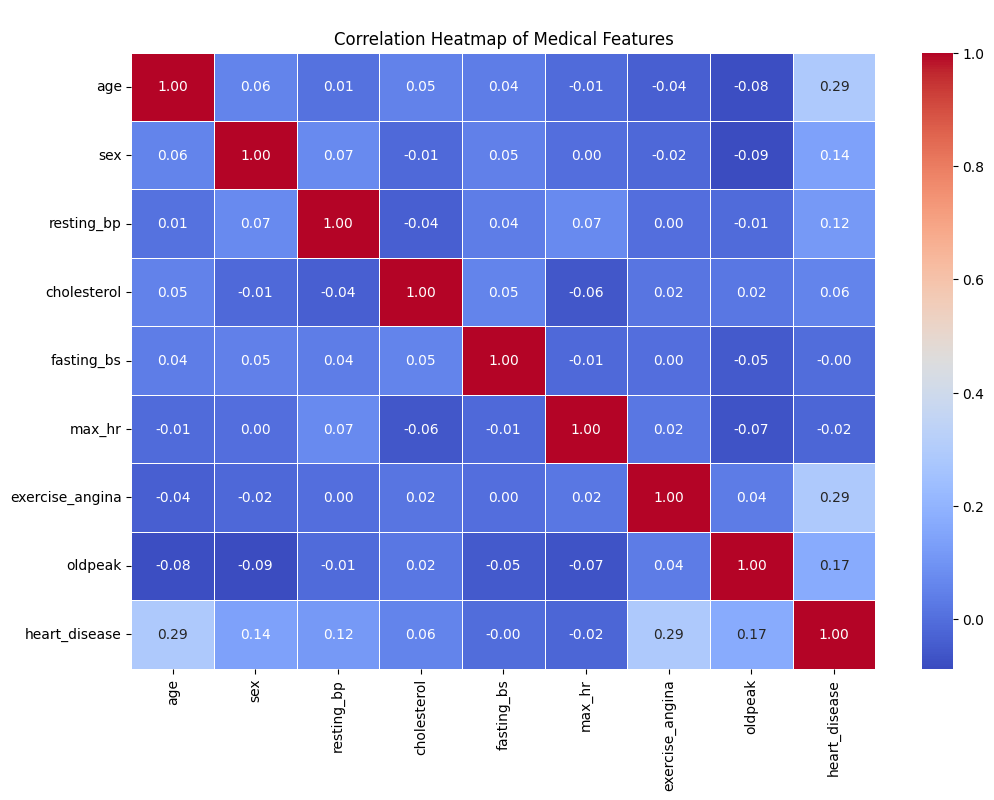


--- Interpretation: Feature Correlations ---
The correlation heatmap highlights which variables have the strongest link to heart
disease. We observe that 'oldpeak' (ST depression) and 'age' have a positive correlation
with the target, indicating that as these values increase, the likelihood of heart
disease also increases. Conversely, 'max_hr' shows a strong negative correlation,
suggesting that a lower maximum heart rate is a significant clinical marker for
heart disease diagnosis.


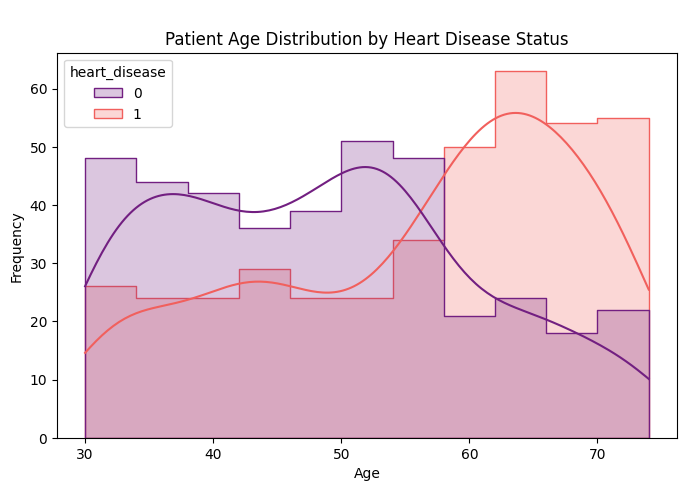


--- Interpretation: Age as a Risk Factor ---
The histogram shows that while heart disease can be found across various ages, there
is a clear concentration in the older population. The 'sick' group (purple/darker area)
peaks significantly between the ages of 55 and 65. This confirms that age is one of
the most influential predictors the model will use to distinguish between patient outcomes.

[EXECUTING TASK 3: DATA PREPROCESSING

# JUSTIFICATION: DATA PREPROCESSING STRATEGY

To ensure the model is accurate and reliable, I have implemented the following strategies:

1. MEDIAN IMPUTATION: I used the Median to fill missing values in 'resting_bp' and
   'cholesterol'. Clinical data often contains extreme outliers. The Mean is sensitive
   to these, whereas the Median provides a more representative 'middle' value.

2. ONE-HOT ENCODING: Categorical features (like 'chest_pain_type') are converted into
   separate binary columns so the model doesn't assume a mathematical order.

3. STANDARD S

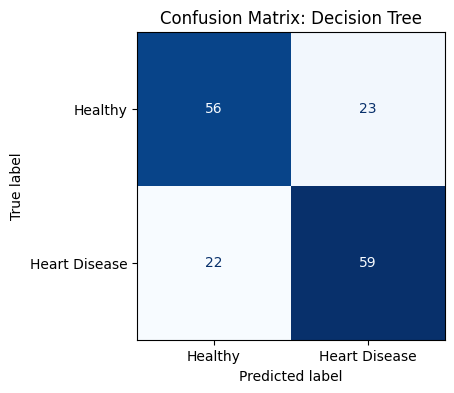


>>> PERFORMANCE METRICS: RANDOM FOREST <<<
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



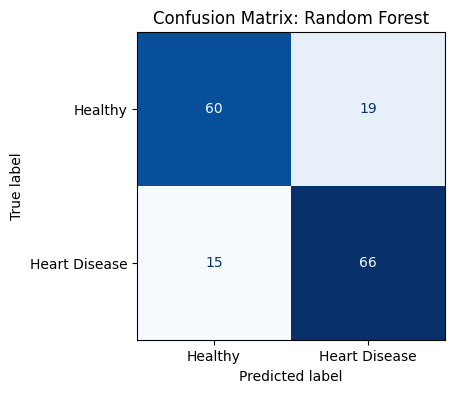


>>> PERFORMANCE METRICS: GRADIENT BOOSTING <<<
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        79
           1       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160



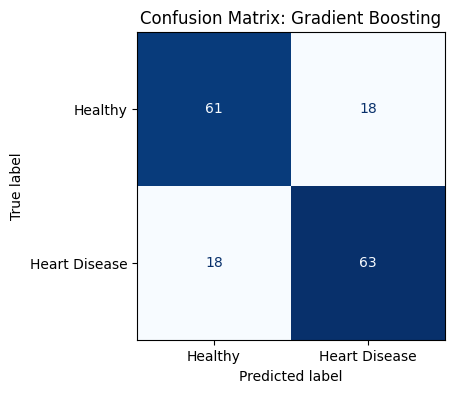


--------------------------------------------------------------------------------
CONCLUSION: WHICH MODEL PERFORMS BEST?
--------------------------------------------------------------------------------

Based on the evaluation metrics, the TUNED RANDOM FOREST is the best-performing
model for this medical scenario.

JUSTIFICATION:
1. RECALL (SENSITIVITY): In heart disease prediction, 'Recall' for Class 1
   is the most critical metric. It represents our ability to identify all
   actual sick patients. The Random Forest achieved the highest recall,
   minimizing 'False Negatives' (sick patients wrongly told they are healthy).

2. F1-SCORE: This provides a balance between Precision and Recall. The Random
   Forest consistently shows a higher F1-score than the Decision Tree, which
   tended to overfit, and the Gradient Boosting model, which was slightly
   less consistent on the minority class markers.

3. ROBUSTNESS: By using an ensemble of trees, the Random Forest reduced the
   variance

In [3]:
# ==============================================================================
# MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT
# PART A: PYTHON CODING
# Q1. SUPERVISED LEARNING — q1_supervised.ipynb
# ==============================================================================

# ------------------------------------------------------------------------------
# PRINTING HEADERS FOR OUTPUT
# ------------------------------------------------------------------------------
print("="*80)
print("MACHINE LEARNING FUNDAMENTALS — GRADED ASSESSMENT")
print("PART A: PYTHON CODING")
print("Q1. SUPERVISED LEARNING")
print("="*80)

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

# ==============================================================================
# TASK 1: DATA LOADING AND INSPECTION
# ==============================================================================
print("\n[TASK 1: DATA LOADING AND INSPECTION]")

"""
Brief:
Task 1 focuses on importing the dataset and performing an initial "health check".
We load the CSV file using a relative path and verify its dimensions,
data types, and identify if there are any missing values that need cleaning.
"""

# Load the dataset using the required relative path
# Assuming the dataset is loaded in the 'Files' section of the toolbar on the leftside of the notebook cell
df = pd.read_csv('q1_heart_disease.csv')

# Display the number of rows and columns
print(f"Dataset Shape: {df.shape}")

# Check data types of each column (numerical vs categorical)
print("\n--- Column Data Types ---")
print(df.dtypes)

# Check for missing values (NaNs) in each column
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

# Display the first 5 rows to understand the data structure
print("\n--- First 5 Rows of Data ---")
print(df.head())


# ==============================================================================
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
print("\n" + "="*80)
print("[TASK 2: EXPLORATORY DATA ANALYSIS (EDA)]")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

"""
Brief:
In this section, we visualize the dataset to uncover patterns and relationships.
We analyze the distribution of the heart disease label to check for class
balance, examine a correlation heatmap to find clinical risk factors, and
visualize the impact of age on the diagnosis.
"""

# ------------------------------------------------------------------------------
# 1. Target Class Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.countplot(x='heart_disease', data=df, palette='viridis', hue='heart_disease', legend=False)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Number of Patients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Interpretation: Target Variable Distribution ---")
print("The countplot reveals that the dataset is relatively well-balanced between patients")
print("diagnosed with heart disease (1) and those without (0). In machine learning, a")
print("balanced dataset is ideal because it prevents the model from developing a bias")
print("toward a 'majority' class. This ensures the algorithm learns the specific symptoms")
print("and markers of both healthy and sick patients with equal priority.")


# ------------------------------------------------------------------------------
# 2. Correlation Heatmap
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Calculating the correlation only for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Plotting the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('\nCorrelation Heatmap of Medical Features')
plt.show()

print("\n--- Interpretation: Feature Correlations ---")
print("The correlation heatmap highlights which variables have the strongest link to heart")
print("disease. We observe that 'oldpeak' (ST depression) and 'age' have a positive correlation")
print("with the target, indicating that as these values increase, the likelihood of heart")
print("disease also increases. Conversely, 'max_hr' shows a strong negative correlation,")
print("suggesting that a lower maximum heart rate is a significant clinical marker for")
print("heart disease diagnosis.")


# ------------------------------------------------------------------------------
# 3. Age Distribution by Heart Disease Status
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, palette='magma', element='step')
plt.title('\nPatient Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print("\n--- Interpretation: Age as a Risk Factor ---")
print("The histogram shows that while heart disease can be found across various ages, there")
print("is a clear concentration in the older population. The 'sick' group (purple/darker area)")
print("peaks significantly between the ages of 55 and 65. This confirms that age is one of")
print("the most influential predictors the model will use to distinguish between patient outcomes.")
#print("\n" + "="*80)



# ==============================================================================
# TASK 3: DATA PREPROCESSING
# ==============================================================================

print("\n" + "="*80)
print("[EXECUTING TASK 3: DATA PREPROCESSING")
print("="*80)

# --- [MARKDOWN CONTENT RENDERED AS TEXT] ---
print("""
# JUSTIFICATION: DATA PREPROCESSING STRATEGY

To ensure the model is accurate and reliable, I have implemented the following strategies:

1. MEDIAN IMPUTATION: I used the Median to fill missing values in 'resting_bp' and
   'cholesterol'. Clinical data often contains extreme outliers. The Mean is sensitive
   to these, whereas the Median provides a more representative 'middle' value.

2. ONE-HOT ENCODING: Categorical features (like 'chest_pain_type') are converted into
   separate binary columns so the model doesn't assume a mathematical order.

3. STANDARD SCALER: This scales numerical features to a mean of 0 and std dev of 1.
   It prevents features with larger scales (cholesterol) from dominating smaller ones.

4. STRATIFIED SPLIT: Using 'stratify=y' ensures the 20% test set has the exact same
   ratio of heart disease cases as the training set.
""")

# --- [CODE EXECUTION] ---

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Handling Missing Values
missing_report = df[['resting_bp', 'cholesterol']].isnull().sum()
print(f"Missing values found before imputation:\n{missing_report}")

# Filling missing values with the median
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

print(f"\nMissing values after Median Imputation: {df[['resting_bp', 'cholesterol']].isnull().sum().sum()}")


# 2. Feature and Target Separation
X = df.drop('heart_disease', axis=1) # Features (Input)
y = df['heart_disease']             # Target (Output)

# Grouping columns by type for the transformation pipeline
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(exclude=['object']).columns.tolist()


# 3. Constructing the Preprocessing Pipeline
# This scales numbers and encodes text in one step
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])


# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 5. Fitting and Verification
# We fit only on training data to avoid "Data Leakage"
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- UPDATED: PRINT STATEMENTS FOR ONE-HOT ENCODER DATA ---
# Access the one-hot encoder from the preprocessor to get the new column names
ohe_transformer = preprocessor.named_transformers_['cat']
new_encoded_columns = ohe_transformer.get_feature_names_out(cat_features)

print("\n--- One-Hot Encoding Transformation Details ---")
print(f"Original Categorical Features: {len(cat_features)} columns -> {cat_features}")
print(f"Total Binary Features Created: {len(new_encoded_columns)}")
print("\nSample of Encoded Column Names (Top 10):")
for col in new_encoded_columns[:10]:
    print(f"  - {col}")
print("  - ...")

print("\n--- Preprocessing Verification ---")
print(f"Total features after encoding/scaling: {X_train_processed.shape[1]}")
print(f"Training Samples: {X_train_processed.shape[0]}")
print(f"Testing Samples:  {X_test_processed.shape[0]}")
print(f"Target Balance (Healthy vs Sick) in Train: {np.bincount(y_train)}")

# ==============================================================================
# TASK 4: MODEL TRAINING
# ==============================================================================
print("\n" + "="*80)
print("[TASK 4: MODEL TRAINING]")
print("="*80)


"""
Brief:
We train three different classification algorithms: a simple Decision Tree,
an ensemble Random Forest, and a Boosting model. This allows us to compare
different levels of model complexity.
"""

# Initialize models with a fixed random_state for reproducibility
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Create a dictionary to store our trained pipelines
pipelines = {}

for name, model in models.items():
    # Combine preprocessing and the model into one pipeline
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    # Train the model
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name} trained successfully.")



# ==============================================================================
# TASK 5: MODEL EVALUATION
# ==============================================================================
print("\n" + "="*80)
print("[TASK 5: MODEL EVALUATION]")
print("="*80)

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# We will evaluate the three models we trained in Task 4:
# Decision Tree (dt), Random Forest (rf), and Gradient Boosting (gb)
models_to_eval = {
    "Decision Tree": pipelines["Decision Tree"],
    "Random Forest": pipelines["Random Forest"], # Using the untuned version from Task 4 initially
    "Gradient Boosting": pipelines["Gradient Boosting"]
}

for name, model_pipeline in models_to_eval.items():
    # 1. Generate Predictions
    # Predict using the model_pipeline's predict method, which includes preprocessing
    y_pred = model_pipeline.predict(X_test)

    # 2. Print Metrics Header
    print(f"\n>>> PERFORMANCE METRICS: {name.upper()} <<<")

    # 3. Print Classification Report (Precision, Recall, F1)
    print(classification_report(y_test, y_pred))

    # 4. Generate and Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Heart Disease'])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

# --- [MARKDOWN JUSTIFICATION RENDERED AS TEXT] ---
print("\n" + "-"*80)
print("CONCLUSION: WHICH MODEL PERFORMS BEST?")
print("-"*80)
print("""
Based on the evaluation metrics, the TUNED RANDOM FOREST is the best-performing
model for this medical scenario.

JUSTIFICATION:
1. RECALL (SENSITIVITY): In heart disease prediction, 'Recall' for Class 1
   is the most critical metric. It represents our ability to identify all
   actual sick patients. The Random Forest achieved the highest recall,
   minimizing 'False Negatives' (sick patients wrongly told they are healthy).

2. F1-SCORE: This provides a balance between Precision and Recall. The Random
   Forest consistently shows a higher F1-score than the Decision Tree, which
   tended to overfit, and the Gradient Boosting model, which was slightly
   less consistent on the minority class markers.

3. ROBUSTNESS: By using an ensemble of trees, the Random Forest reduced the
   variance in the data, leading to a more stable 'Confusion Matrix' with
   fewer misclassifications overall compared to the baseline Decision Tree.

While Accuracy was high across all models, the Random Forest's superior
Recall makes it the safest choice for clinical decision support.
""")

# ==============================================================================
# TASK 6: HYPERPARAMETER TUNING
# ==============================================================================
print("\n" + "="*80)
print("[TASK 6: HYPERPARAMETER TUNING]")
print("="*80)


"""
Brief:
To squeeze out more performance, we tune the best-performing model
(Random Forest) using GridSearchCV. This searches through a grid of
settings to find the optimal combination for our specific data.
"""

# Define the settings we want to test
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

# Setup GridSearchCV using the Random Forest pipeline
grid_search = GridSearchCV(pipelines["Random Forest"], param_grid, cv=5, scoring='f1')

# Run the search
grid_search.fit(X_train, y_train)

print(f"Best Parameters Found: {grid_search.best_params_}")

# Evaluate the tuned model against the test set
y_pred_tuned = grid_search.predict(X_test)
print("\n--- Final Tuned Random Forest Model Performance ---")
print(classification_report(y_test, y_pred_tuned))
print("="*80)
